MNIST CODE


In [1]:
import tensorflow as tf

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.utils import to_categorical

In [3]:
(X_train, y_train), (X_test, y_test) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [5]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

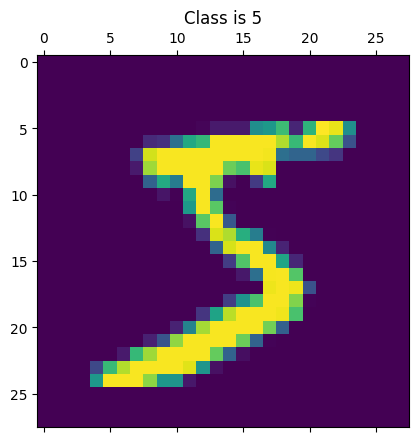

In [6]:
plt.matshow(X_train[0])
plt.title(f"Class is {y_train[0]}")
plt.show()

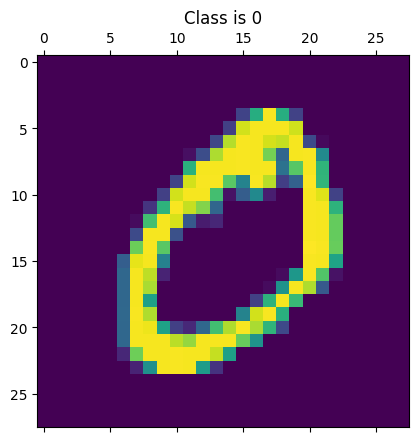

In [7]:
plt.matshow(X_train[1])
plt.title(f"Class is {y_train[1]}")
plt.show()

In [8]:
np.max(X_train), np.min(X_train)
X_train = X_train / 255
X_test = X_test / 255
np.max(X_train), np.min(X_train)

(np.float64(1.0), np.float64(0.0))

In [10]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [11]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [12]:
y_train[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [14]:
model = Sequential()

model.add(Dense(256, activation="relu", input_shape=(784,), name="h1"))
model.add(Dense(128, activation="relu", name="h2"))
model.add(Dense(10, activation="softmax"))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.layers[0].get_weights()

[array([[ 0.0513276 ,  0.04225269,  0.01646296, ...,  0.00661866,
         -0.07437628, -0.03550941],
        [ 0.07405171,  0.05310731, -0.02711038, ...,  0.03652821,
         -0.0248511 ,  0.06072527],
        [-0.04884599, -0.05937598,  0.03719309, ..., -0.01963534,
          0.0700364 ,  0.06540616],
        ...,
        [ 0.07343085, -0.01393352,  0.05846447, ...,  0.05233124,
         -0.06994854, -0.04309064],
        [-0.03889707,  0.05838178,  0.04015983, ..., -0.06015228,
         -0.0388873 ,  0.0458511 ],
        [ 0.06661472, -0.0513981 ,  0.06912874, ...,  0.03908774,
          0.05030549,  0.00919429]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [16]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8938 - loss: 0.3518 - val_accuracy: 0.9705 - val_loss: 0.0977
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9725 - loss: 0.0912 - val_accuracy: 0.9775 - val_loss: 0.0818
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9818 - loss: 0.0620 - val_accuracy: 0.9766 - val_loss: 0.0875
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9866 - loss: 0.0455 - val_accuracy: 0.9793 - val_loss: 0.0859
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9881 - loss: 0.0421 - val_accuracy: 0.9789 - val_loss: 0.0896
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9904 - loss: 0.0319 - val_accuracy: 0.9819 - val_loss: 0.0788
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9925 - loss: 0.0266 - val_accuracy: 0.9786 - val_loss: 0.0999
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9932 - loss: 0.0223 -

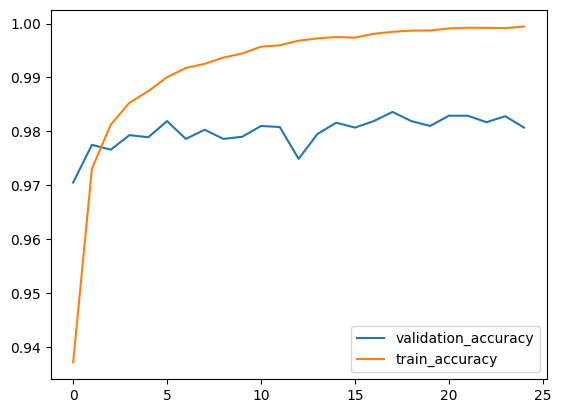

In [18]:
h = history.history

plt.plot(h['val_accuracy'], label='validation_accuracy')
plt.plot(h['accuracy'], label='train_accuracy')
plt.legend()
plt.show()

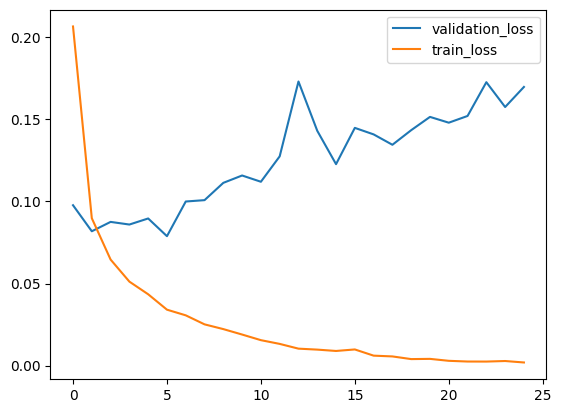

In [19]:
plt.plot(h['val_loss'], label='validation_loss')
plt.plot(h['loss'], label='train_loss')
plt.legend()
plt.show()

In [20]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9765 - loss: 0.2093


[0.16971971094608307, 0.9807000160217285]

CIFAR-10 + VGG16 Transfer Learning

In [21]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [22]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [23]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [24]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [25]:
X_train.shape

(50000, 32, 32, 3)

In [26]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
for layer in base_model.layers:
    layer.trainable = False

In [28]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [30]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [31]:
 mmodel.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 672s 429ms/step - accuracy: 0.4117 - loss: 1.6606 - val_accuracy: 0.5454 - val_loss: 1.2882
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 680s 428ms/step - accuracy: 0.5411 - loss: 1.3076 - val_accuracy: 0.5735 - val_loss: 1.2173
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 626s 401ms/step - accuracy: 0.5669 - loss: 1.2522 - val_accuracy: 0.5793 - val_loss: 1.1849
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 679s 399ms/step - accuracy: 0.5805 - loss: 1.2063 - val_accuracy: 0.5876 - val_loss: 1.1713
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 722s 425ms/step - accuracy: 0.5840 - loss: 1.1878 - val_accuracy: 0.5952 - val_loss: 1.1511
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 641s 399ms/step - accuracy: 0.5956 - loss: 1.1648 - val_accuracy: 0.6017 - val_loss: 1.1418
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 722s 425ms/step - accuracy: 0.5962 - loss: 1.1469 - val_accuracy: 0.6046 - val_loss: 1.1377
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 642s 399ms/step - ac

In [33]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 335ms/step - accuracy: 0.6046 - loss: 1.1039
Test Loss: 1.1160118579864502, Test Accuracy: 0.6050999760627747
